In [40]:
import sys
sys.path.append("../")

import importlib
from functools import partial

import matplotlib.pyplot as plt
import numpy as np  
from IPython.display import display
import pandas as pd 

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx

In [41]:
# Reproducibility
SEED = 123123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True 
np.random.seed(SEED)

In [42]:
DATASET_NAME = "BA-2MOTIFS"

In [43]:
config = {
    "DATASET_NAME": DATASET_NAME, 
    "device": "cuda",
    "explainee": {
        "epochs": 100, 
        "batch_size": 64, 
        "lr": 1e-4
    }, 
    "ged_model": {
        "n_perds": 4, 
        "epochs": 100, 
        "batch_size": 64, 
    }, 
    "tune": {
        "n_trials": 8, 
        "max_nodes": 24, 
        "iters_per_sample": 16, 
        "samples_per_trial": 8, # Note: per class. 
    },
    "train": {
        "iters_per_sample": 200, 
        "samples_per_trial": 50, # Note: per class. 
    }
}

# Data

In [44]:
import new_src.dataAdapter
from new_src.dataAdapter import load_dataset
importlib.reload(new_src.dataAdapter)

data = load_dataset(config.get("DATASET_NAME"))
cls_split = data.split_by_class()

# Explainee

In [45]:
import new_src.explainee
from new_src.explainee import fit_explainee
importlib.reload(new_src.explainee)

explainee, _ = fit_explainee(
    dataset_name = config.get("DATASET_NAME"),
    root="data",
    hidden=64,
    layers=3,
    dropout=0.2,
    epochs=config["explainee"]["epochs"],
    batch_size=config["explainee"]["batch_size"],
    lr=config["explainee"]["lr"],
    device=config.get("device")
)


# Extract embeddings. 
mean_embeds = [
    torch.cat([explainee(batch.to(config.get("device")))["embeds"]
               for batch in DataLoader(subset, batch_size=64)])
         .mean(dim=0)
    for subset in cls_split
]
mean_embeds = [m.detach() for m in mean_embeds]

[001/100] train_loss=0.7000  val_acc=0.540
[002/100] train_loss=0.6935  val_acc=0.460
[003/100] train_loss=0.6901  val_acc=0.460
[004/100] train_loss=0.6925  val_acc=0.460
[005/100] train_loss=0.6921  val_acc=0.460
[006/100] train_loss=0.6931  val_acc=0.460
[007/100] train_loss=0.6939  val_acc=0.460
[008/100] train_loss=0.6941  val_acc=0.460
[009/100] train_loss=0.6922  val_acc=0.460
[010/100] train_loss=0.6943  val_acc=0.460
[011/100] train_loss=0.6896  val_acc=0.460
[012/100] train_loss=0.6947  val_acc=0.460
[013/100] train_loss=0.6951  val_acc=0.460
[014/100] train_loss=0.6940  val_acc=0.460
[015/100] train_loss=0.6935  val_acc=0.460
[016/100] train_loss=0.6953  val_acc=0.460
[017/100] train_loss=0.6934  val_acc=0.460
[018/100] train_loss=0.6939  val_acc=0.460
[019/100] train_loss=0.6931  val_acc=0.460
[020/100] train_loss=0.6931  val_acc=0.460
[021/100] train_loss=0.6929  val_acc=0.460
[022/100] train_loss=0.6926  val_acc=0.460
[023/100] train_loss=0.6943  val_acc=0.460
[024/100] t

# GED Approximator

Generating synthetic GED dataset with 4 perturbations per graph...
Created GED dataset with 4000 pairs.


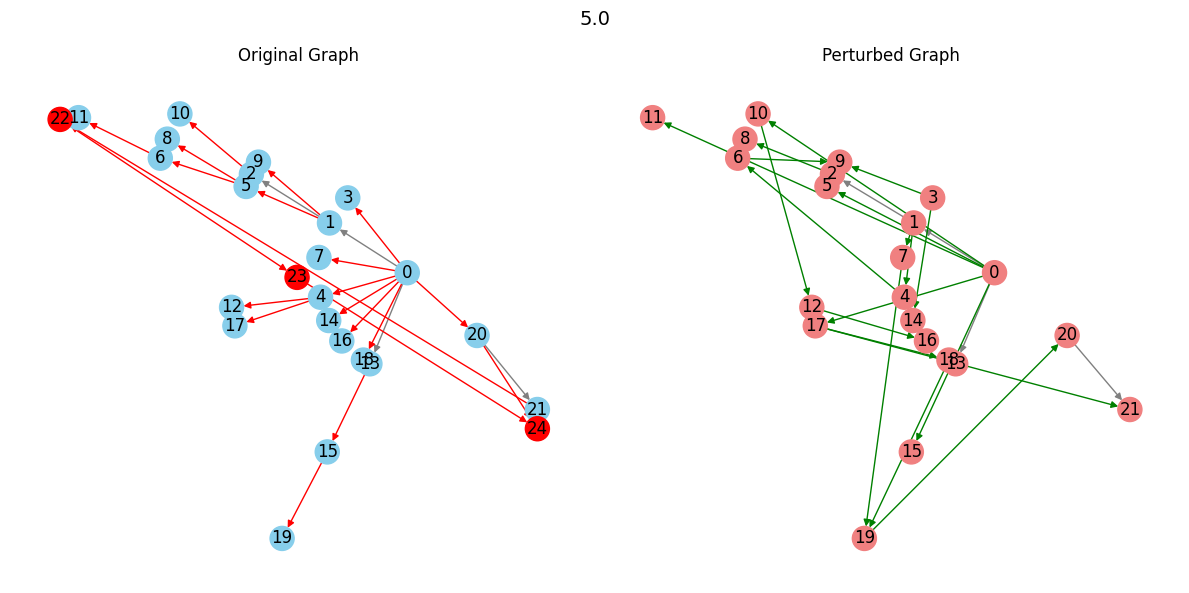

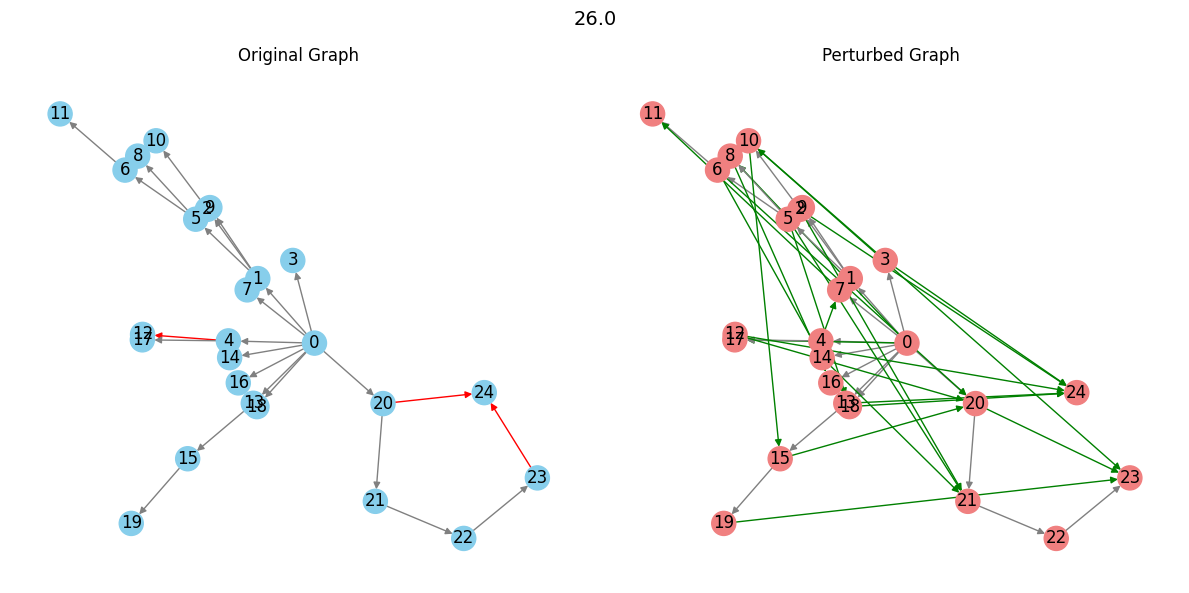

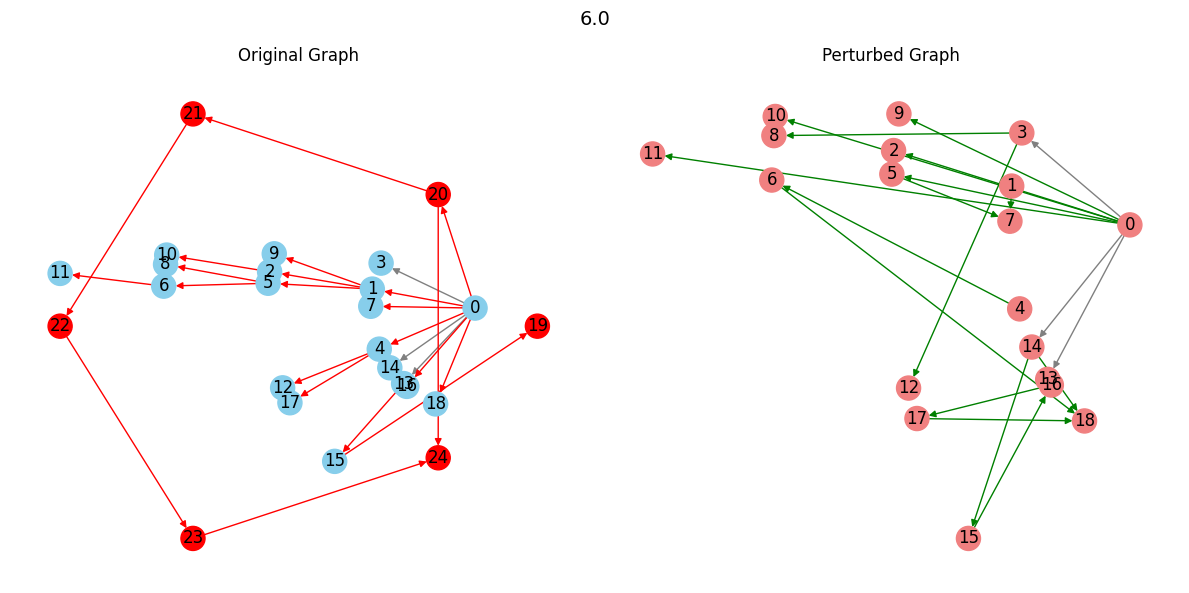

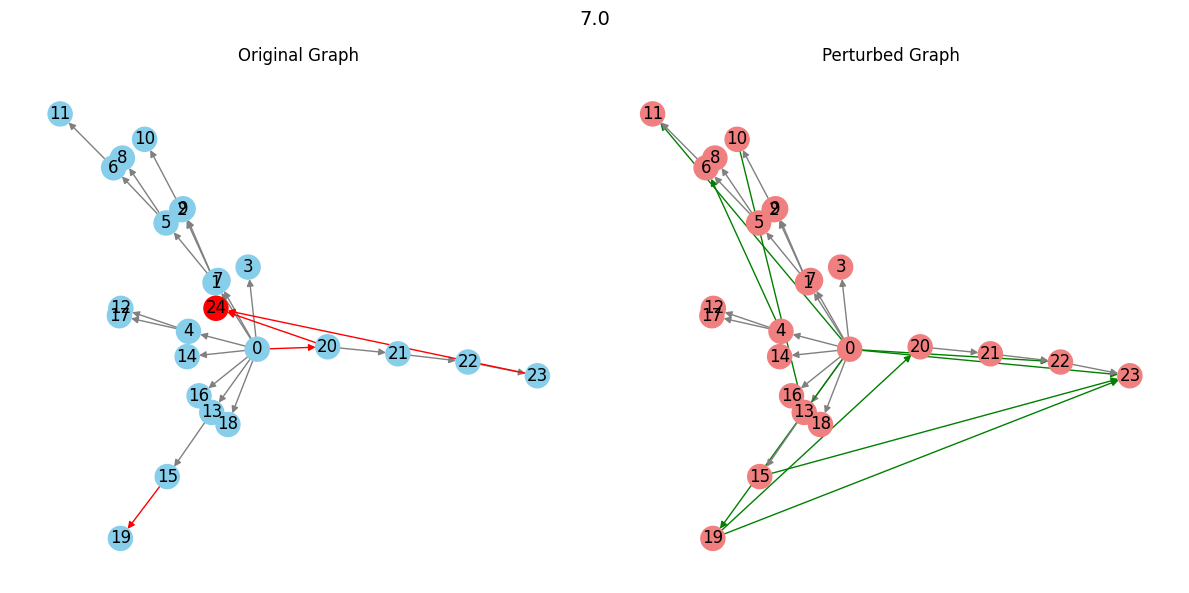

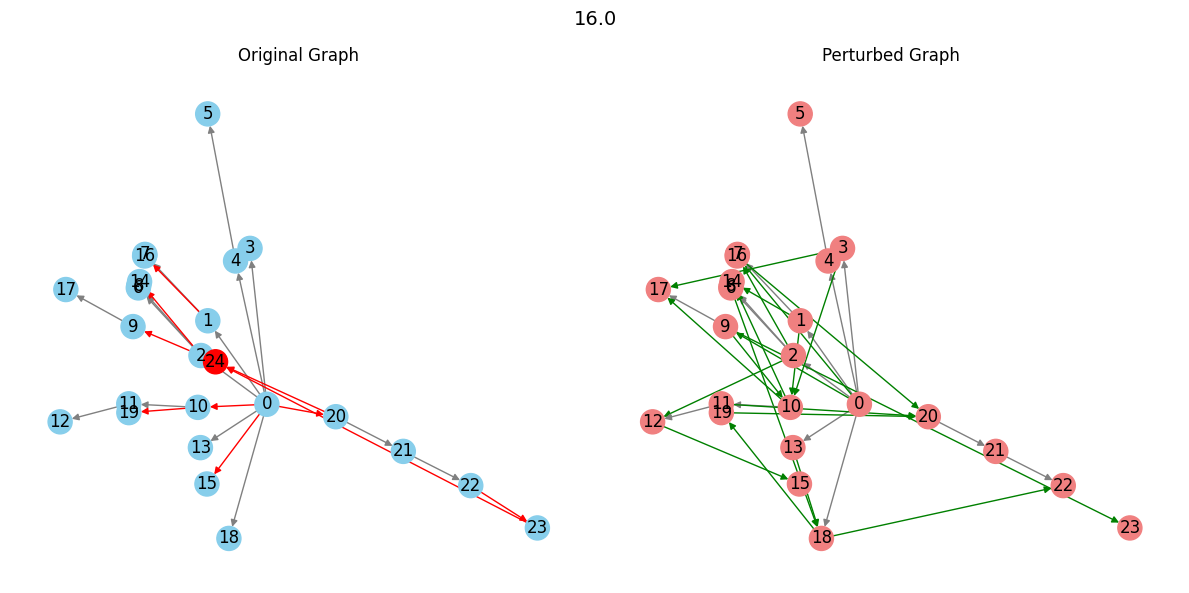

In [46]:
import new_src.ged_dataset
importlib.reload(new_src.ged_dataset)

from new_src.ged_dataset import create_and_save_ged_dataset, plot_graph_pair

ged_dataset = create_and_save_ged_dataset(
    data, 
    out_path=None, 
    n_perturbations=config["ged_model"]["n_perds"],
    node_add_prob=0.5,
    node_remove_prob=0.5,
    edge_add_prob=0.1, 
    edge_remove_prob=0.1
)

print(f"Created GED dataset with {len(ged_dataset)} pairs.")

for i in range(5):
    g1, g2, ged_norm, _, _ = ged_dataset[i]
    raw_ged = getattr(g1, "raw_ged", ged_norm)
    plot_graph_pair(g1, g2, label=raw_ged)

In [47]:
import new_src.simgnn
importlib.reload(new_src.simgnn)

from new_src.simgnn import SimGNN, train_simgnn

model = SimGNN(in_dim=len(data.NODE_CLS))

train_simgnn(
    model=(m := model), 
    data=ged_dataset, 
    batch_size=config["ged_model"]["batch_size"], 
    optimizer=(o := torch.optim.Adam(m.parameters(), lr=1e-3)),
    scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
    epochs=config["ged_model"]["epochs"], 
    device=config.get("device")
)

Training SimGNN:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 001 | Loss: 0.2005 | MSE(norm): 0.2005 | MSE(raw): 155.4501 | Corr(norm): 0.0999 | Corr(raw): 0.3280
Epoch 002 | Loss: 0.1138 | MSE(norm): 0.1138 | MSE(raw): 85.2500 | Corr(norm): 0.4780 | Corr(raw): 0.6703
Epoch 003 | Loss: 0.0720 | MSE(norm): 0.0720 | MSE(raw): 54.3923 | Corr(norm): 0.7180 | Corr(raw): 0.8036
Epoch 004 | Loss: 0.0537 | MSE(norm): 0.0537 | MSE(raw): 40.4383 | Corr(norm): 0.7994 | Corr(raw): 0.8583
Epoch 005 | Loss: 0.0487 | MSE(norm): 0.0487 | MSE(raw): 36.4243 | Corr(norm): 0.8198 | Corr(raw): 0.8734
Epoch 006 | Loss: 0.0490 | MSE(norm): 0.0490 | MSE(raw): 37.2478 | Corr(norm): 0.8198 | Corr(raw): 0.8712
Epoch 007 | Loss: 0.0464 | MSE(norm): 0.0464 | MSE(raw): 34.9812 | Corr(norm): 0.8293 | Corr(raw): 0.8787
Epoch 008 | Loss: 0.0430 | MSE(norm): 0.0430 | MSE(raw): 31.7520 | Corr(norm): 0.8427 | Corr(raw): 0.8902
Epoch 009 | Loss: 0.0449 | MSE(norm): 0.0449 | MSE(raw): 33.0862 | Corr(norm): 0.8353 | Corr(raw): 0.8856
Epoch 010 | Loss: 0.0424 | MSE(norm): 0.0424 

# Generator

In [48]:
# All passes should be explicit. 
def train_generator(
    cls_idx, 
    max_nodes, 
    iters_per_sample, 
    data, 
    mean_embeds, 
    explainee, 
    ged_model, 
    w_pred=1,
    w_embed=1,
    w_ged=1,
    w_mcs=1,
    w_spec=1,
    w_wl=1,
    use_omega=False,  
    use_kl=0,
):

    from new_src.graph_sampler import GraphSampler
    from new_src.trainer import Trainer
    from new_src.criteria import (
        WeightedCriterion, 
        ClassScoreCriterion, 
        EmbeddingCriterion, 
        KLDivergencePenalty, 
        BudgetPenalty
    )
    
    from new_src.graph_level_dist import (
        neural_approx_ged_dist, 
        mcs_soft_graph_dist, 
        spectral_dist, 
        wl_graph_kernel_dist
    )
    
    trainer = Trainer(
        sampler=(
            s := GraphSampler(
                    max_nodes=max_nodes,
                    num_node_cls=len(data.NODE_CLS),
                    num_edge_cls=len(data.EDGE_CLS), 
                    temperature=0.15,
                    learn_node_feat=len(data.NODE_CLS) > 0, 
                    learn_edge_feat=len(data.EDGE_CLS) > 0, 
            )
        ),
        discriminator=explainee,
        criterion=WeightedCriterion([
            dict(key="logits", 
                criterion=ClassScoreCriterion(
                    class_idx=cls_idx, mode='maximize'
                ), 
                weight=w_pred
            ),
            dict(key="embeds", 
                criterion=EmbeddingCriterion(
                    target_embedding=mean_embeds[cls_idx]
                ), 
                weight=w_embed
            ),
            dict(key="theta_pairs", 
                criterion=KLDivergencePenalty(
                    binary=True
                ), 
                weight=use_kl
            ),
            dict(key="cont_data", 
                criterion=neural_approx_ged_dist(
                    data = data, model = ged_model, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_ged
            ), 
            dict(key="cont_data", 
                criterion=mcs_soft_graph_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_mcs
            ), 
            dict(key="cont_data", 
                criterion=spectral_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_spec
            ), 
            dict(key="cont_data", 
                criterion=wl_graph_kernel_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_wl
            ), 
        ]),
        optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
        scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
        dataset=data,
        budget_penalty=BudgetPenalty(budget=20, order=2, beta=1),
        device=config.get("device")
    )

    trainer.train(
        iterations=iters_per_sample,
        target_probs={cls_idx: (0.9, 1.0)},
        target_size=30,
        w_budget_init=0.5,
        w_budget_inc=1.1,
        w_budget_dec=0.95,
        k_samples=32
    )

    example = trainer.evaluate(threshold=0.5)

    example = from_networkx(example)

    if "label" in example: 
        example.x = F.one_hot(
            example.label, num_classes=len(data.NODE_CLS)
        ).float()

    if "edge_label" in example: 
        example.edge_attr = F.one_hot(
            example.edge_label, num_classes=len(data.EDGE_CLS)
        ).float()

    example.y = torch.tensor(cls_idx).float()
    
    return example

## Tuning

In [49]:
import ray
from ray import tune
from ray import air
from ray.tune import ExperimentAnalysis
ray.shutdown()
ray.init(
    runtime_env={
        "py_modules": ["/repo/revisions/new_src"]
    },
    num_gpus=1
)

data_ref = ray.put(data)
mean_embeds_ref = ray.put(mean_embeds)
cls_split_ref = ray.put(data.split_by_class())

2025-11-12 23:36:42,694	WARNING services.py:2155 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 67104768 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=10.24gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2025-11-12 23:36:42,934	INFO worker.py:2012 -- Started a local Ray instance.
2025-11-12 23:36:43,598	INFO packaging.py:588 -- Creating a file package for local module '/repo/revisions/new_src'.
2025-11-12 23:36:44,125	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_a5e88987c1ace4de.zip' (0.39MiB) to Ray cluster...
2025-11-12 23:36:44,128	INFO packaging.py:393 -- Successfully pushed file package 'gcs://_ray_pkg_a5e88987c1ace4de.zip'.
/opt/venv/lib/python3.12/site-packages/ray/_private/worker

In [50]:
def tune_generator(
    config, *,
    explainee, 
    model, 
    max_nodes, 
    gen_samples, 
    iters_per_sample, 
):
    from new_src.eval import eval_summary
    from new_src.graph_level_dist import neural_approx_ged_dist

    data = ray.get(data_ref) 
    mean_embeds = ray.get(mean_embeds_ref)
    cls_split = ray.get(cls_split_ref)
   
    w_pred  = float(config["pred_weight"])
    w_embed = float(config["embed_weight"])
    w_ged   = float(config["ged_weight"])
    w_mcs   = float(config["mcs_weight"])
    w_spec  = float(config["spectral_weight"])
    w_wl    = float(config["wl_weight"])
    use_omega = bool(config["use_omega"])
    use_kl = bool(config["use_kl"])
    
    graphs_0 = [
        train_generator(
            cls_idx=0, 
            max_nodes=max_nodes, 
            iters_per_sample=iters_per_sample, 
            data=data, 
            explainee=explainee, 
            mean_embeds=mean_embeds, 
            ged_model=model, 
            w_pred=w_pred, 
            w_embed=w_embed, 
            w_ged=w_ged, 
            w_mcs=w_mcs, 
            w_spec=w_spec, 
            w_wl=w_wl, 
            use_omega = use_omega,
            use_kl=use_kl
        ) 
        for _ in range(gen_samples)
    ] 

    graphs_1 = [
        train_generator(
            cls_idx=1, 
            max_nodes=max_nodes, 
            iters_per_sample=iters_per_sample, 
            data=data, 
            explainee=explainee, 
            mean_embeds=mean_embeds, 
            ged_model=model, 
            w_pred=w_pred, 
            w_embed=w_embed, 
            w_ged=w_ged, 
            w_mcs=w_mcs, 
            w_spec=w_spec, 
            w_wl=w_wl, 
            use_omega = use_omega,
            use_kl=use_kl
        ) 
        for _ in range(gen_samples)
    ] 
    
    dist_to_0 = neural_approx_ged_dist(cls_split[0], model)
    dist_to_1 = neural_approx_ged_dist(cls_split[1], model)
     
    score = eval_summary(
        explainee, graphs_0, graphs_1,
        cls_split[0], cls_split[1], 
        dist_to_0, dist_to_1
    ) 
    
    results = {
        "score": float(score)
    }

    tune.report(results)

    return results

In [51]:
possible_weight = [0.0, 1e-2, 1e-1, 1.0, 1e+1, 1e+2]
search_space = {
    "pred_weight": tune.choice(possible_weight),
    "embed_weight": tune.choice(possible_weight),
    "ged_weight": tune.choice(possible_weight),
    "mcs_weight": tune.choice(possible_weight),
    "spectral_weight": tune.choice(possible_weight),
    "wl_weight": tune.choice(possible_weight),
    "use_omega": tune.choice([True, False]),
    "use_kl": tune.choice([0, 1]), 
}

trainable = tune.with_parameters(
    tune_generator, 
    explainee=explainee,
    model=model, 
    max_nodes=config["tune"]["max_nodes"],
    gen_samples=config["tune"]["samples_per_trial"], 
    iters_per_sample=config["tune"]["iters_per_sample"]
)

gen_tuner = tune.Tuner(
    trainable=tune.with_resources(
        trainable, 
        resources={"gpu": 1}
    ), 
    param_space=search_space,
    tune_config=tune.TuneConfig(
        num_samples=config["tune"]["n_trials"],  
        metric="score",
        mode="max"
    ), 
)

In [52]:
tune_results = gen_tuner.fit()

(pid=gcs_server) [2025-11-12 23:37:12,262 E 53371 53371] (gcs_server) gcs_server.cc:302: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(raylet) [2025-11-12 23:37:13,630 E 53576 53576] (raylet) main.cc:975: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(pid=53778) [2025-11-12 23:37:16,615 E 53778 54075] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
[2025-11-12 23:37:17,668 E 50762 53742] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. E

(tune_generator pid=57897) Prediction Interval Class 0 0.5113241076469421 +/- 0.004972091410309076
(tune_generator pid=57897) 
(tune_generator pid=57897) Prediction Interval Class 1 0.48180311918258667 +/- 0.0075348541140556335
(tune_generator pid=57897) 
(tune_generator pid=57897) Counterfactual Shift to Class 0 0.025000451132655144 +/- 0.0047480701468884945
(tune_generator pid=57897) 
(tune_generator pid=57897) Counterfactual Shift to Class 1 -0.031120281666517258 +/- 0.007293790578842163
(tune_generator pid=57897) 
(tune_generator pid=57897) Class 0 Perturbation Sensitivity 0.0022205784916877747 +/- 0.0026839571073651314
(tune_generator pid=57897) 
(tune_generator pid=57897) Class 1 Perturbation Sensitivity 0.002374114003032446 +/- 0.0022275648079812527
(tune_generator pid=57897) 
(tune_generator pid=57897) Relative Distance to Class 0 -0.06015084311366081 +/- 0.0345776192843914 
(tune_generator pid=57897) 
(tune_generator pid=57897) Relative Distance to Class 1 0.04511217027902603 

 25%|██▌       | 4/16 [00:03<00:09,  1.22it/s, size=0.228, bpw=0.5, house=nan, cycle=nan]     
(tune_generator pid=58388) [2025-11-12 23:42:35,843 E 58388 58432] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
 94%|█████████▍| 15/16 [00:13<00:00,  1.19it/s, size=nan, bpw=0.5, house=nan, cycle=nan]
2025-11-12 23:43:29,016	ERROR tune_controller.py:1331 -- Trial task failed for trial tune_generator_7d366_00002
Traceback (most recent call last):
  File "/opt/venv/lib/python3.12/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/opt/venv/lib/python3.12/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/opt/venv/lib/python

(tune_generator pid=58776) 
(tune_generator pid=58776) 
(tune_generator pid=58776) 
(tune_generator pid=58776) 
(tune_generator pid=58776) 
(tune_generator pid=58776) 
(tune_generator pid=58776) 
(tune_generator pid=58776) 
(tune_generator pid=58776) Prediction Interval Class 1 0.5084694623947144 +/- 0.005695308092981577 [repeated 2x across cluster]
(tune_generator pid=58776) Counterfactual Shift to Class 1 -0.011643107049167156 +/- 0.006673899479210377 [repeated 2x across cluster]
(tune_generator pid=58776) Class 1 Perturbation Sensitivity 0.00148102268576622 +/- 0.0015663888771086931 [repeated 2x across cluster]
(tune_generator pid=58776) Relative Distance to Class 1 0.04888458922505379 +/- 0.05391263589262962  [repeated 2x across cluster]


 12%|█▎        | 2/16 [00:01<00:11,  1.19it/s, size=4.13, bpw=0.5, house=0.0484, cycle=0.0286] 
(tune_generator pid=59267) [2025-11-12 23:48:58,506 E 59267 59312] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
100%|██████████| 16/16 [00:13<00:00,  1.17it/s, size=7.88, bpw=0.5, house=0.0466, cycle=0.0874]


(tune_generator pid=59267) 
(tune_generator pid=59267) 
(tune_generator pid=59267) 
(tune_generator pid=59267) 
(tune_generator pid=59267) 
(tune_generator pid=59267) 
(tune_generator pid=59267) 
(tune_generator pid=59267) 
(tune_generator pid=59267) Prediction Interval Class 1 0.5007721185684204 +/- 0.008356978185474873 [repeated 2x across cluster]
(tune_generator pid=59267) Counterfactual Shift to Class 1 -0.014709061942994595 +/- 0.006640094332396984 [repeated 2x across cluster]
(tune_generator pid=59267) Class 1 Perturbation Sensitivity 0.00248419726267457 +/- 0.0024553558323532343 [repeated 2x across cluster]
(tune_generator pid=59267) Relative Distance to Class 1 0.036321286112070084 +/- 0.025772912427783012  [repeated 2x across cluster]


 25%|██▌       | 4/16 [00:03<00:10,  1.17it/s, size=3.67, bpw=0.5, house=0.0296, cycle=0.0419] 
(tune_generator pid=59779) [2025-11-12 23:53:20,570 E 59779 59818] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
100%|██████████| 16/16 [00:15<00:00,  1.05it/s, size=11.2, bpw=0.5, house=0.0608, cycle=0.0204]


(tune_generator pid=59779) 
(tune_generator pid=59779) 
(tune_generator pid=59779) 
(tune_generator pid=59779) 
(tune_generator pid=59779) 
(tune_generator pid=59779) 
(tune_generator pid=59779) 
(tune_generator pid=59779) 
(tune_generator pid=59779) Prediction Interval Class 1 0.48798203468322754 +/- 0.0026761777698993683 [repeated 2x across cluster]
(tune_generator pid=59779) Counterfactual Shift to Class 1 -0.026209816336631775 +/- 0.0020110630430281162 [repeated 2x across cluster]
(tune_generator pid=59779) Class 1 Perturbation Sensitivity 0.002422671765089035 +/- 0.002743212739005685 [repeated 2x across cluster]
(tune_generator pid=59779) Relative Distance to Class 1 0.030581049621105194 +/- 0.03390354663133621  [repeated 2x across cluster]


 25%|██▌       | 4/16 [00:03<00:09,  1.22it/s, size=0.144, bpw=0.5, house=nan, cycle=nan]
(tune_generator pid=60283) [2025-11-12 23:57:40,397 E 60283 60327] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
100%|██████████| 16/16 [00:13<00:00,  1.21it/s, size=nan, bpw=0.5, house=nan, cycle=nan]
2025-11-12 23:58:18,299	ERROR tune_controller.py:1331 -- Trial task failed for trial tune_generator_7d366_00007
Traceback (most recent call last):
  File "/opt/venv/lib/python3.12/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/opt/venv/lib/python3.12/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/opt/venv/lib/python3.12/

Best configuration: {'pred_weight': 100.0, 'embed_weight': 0.0, 'ged_weight': 1.0, 'mcs_weight': 0.0, 'spectral_weight': 100.0, 'wl_weight': 1.0, 'use_omega': False, 'use_kl': 0}


,score,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,time_this_iter_s,time_total_s,pid,...,iterations_since_restore,config/pred_weight,config/embed_weight,config/ged_weight,config/mcs_weight,config/spectral_weight,config/wl_weight,config/use_omega,config/use_kl,logdir
0,0.997451,1762990922,None,False,2,7d366_00001,2025-11-12_23-42-02,0.000653,244.655064,57897,...,2,0.01,100.0,1.0,0.01,0.10,0.1,False,0,7d366_00001
1,1.081960,1762991304,None,False,2,7d366_00004,2025-11-12_23-48-24,0.000868,245.492361,58776,...,2,100.00,0.0,1.0,0.00,100.00,1.0,False,0,7d366_00004
2,1.055765,1762991566,None,False,2,7d366_00005,2025-11-12_23-52-46,0.000701,253.161315,59267,...,2,1.00,1.0,100.0,0.01,0.01,1.0,True,0,7d366_00005
3,1.043862,1762991826,None,False,2,7d366_00006,2025-11-12_23-57-06,0.000774,253.069901,59779,...,2,0.00,100.0,10.0,10.00,0.10,1.0,True,0,7d366_00006


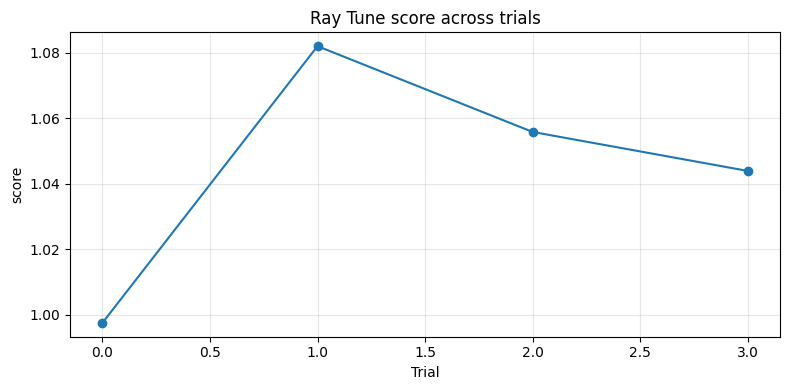

In [53]:
best_config = tune_results.get_best_result().config
print("Best configuration:", best_config)

df = tune_results.get_dataframe()
display(df)

df_sorted = df.reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(df_sorted.index.to_numpy(), df_sorted["score"].to_numpy(), marker="o")
plt.xlabel("Trial")
plt.ylabel("score")
plt.title("Ray Tune score across trials")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluation

In [54]:

graphs_0 = [
    train_generator(
        cls_idx=0, 
        max_nodes=config['tune']['max_nodes'], 
        iters_per_sample=config['train']['iters_per_sample'], 
        data=data, 
        mean_embeds=mean_embeds, 
        explainee=explainee, 
        ged_model=model, 
        w_pred  = float(best_config["pred_weight"]), 
        w_embed = float(best_config["embed_weight"]),
        w_ged   = float(best_config["ged_weight"]), 
        w_mcs   = float(best_config["mcs_weight"]),
        w_spec  = float(best_config["spectral_weight"]),
        w_wl    = float(best_config["wl_weight"]),
        use_omega = bool(best_config["use_omega"]),
        use_kl = bool(best_config["use_kl"]),
    ) for _ in range(config['train']['samples_per_trial'])
]

graphs_1 = [
    train_generator(
        cls_idx=1, 
        max_nodes=config['tune']['max_nodes'], 
        iters_per_sample=config['train']['iters_per_sample'], 
        data=data, 
        mean_embeds=mean_embeds, 
        explainee=explainee, 
        ged_model=model, 
        w_pred  = float(best_config["pred_weight"]), 
        w_embed = float(best_config["embed_weight"]),
        w_ged   = float(best_config["ged_weight"]), 
        w_mcs   = float(best_config["mcs_weight"]),
        w_spec  = float(best_config["spectral_weight"]),
        w_wl    = float(best_config["wl_weight"]),
        use_kl = bool(best_config["use_kl"]),
    ) for _ in range(config['train']['samples_per_trial'])
]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [56]:
from new_src.graph_level_dist import neural_approx_ged_dist
dist_to_0 = neural_approx_ged_dist(cls_split[0], model)
dist_to_1 = neural_approx_ged_dist(cls_split[1], model)

import new_src.eval
importlib.reload(new_src.eval)

from new_src.eval import eval_summary

eval_summary(
    explainee=explainee, 
    gen_graphs_0=graphs_0,
    gen_graphs_1=graphs_1, 
    obs_graphs_0=cls_split[0], 
    obs_graphs_1=cls_split[1], 
    dist_to_0=dist_to_0, 
    dist_to_1=dist_to_1
)

Prediction Interval Class 0 0.582730770111084 +/- 0.011415624991059303

Prediction Interval Class 1 0.5196120738983154 +/- 0.007347702514380217

Counterfactual Shift to Class 0 0.10198898613452911 +/- 0.01134011335670948

Counterfactual Shift to Class 1 -0.006223251111805439 +/- 0.006775148678570986

Class 0 Perturbation Sensitivity 0.0021008537150919437 +/- 0.002242271089926362

Class 1 Perturbation Sensitivity 0.001690111355856061 +/- 0.0022441225592046976

Relative Distance to Class 0 -0.02441752701997757 +/- 0.057926859706640244 

Relative Distance to Class 1 0.04516946151852608 +/- 0.047079455107450485 



1.1735656794626266

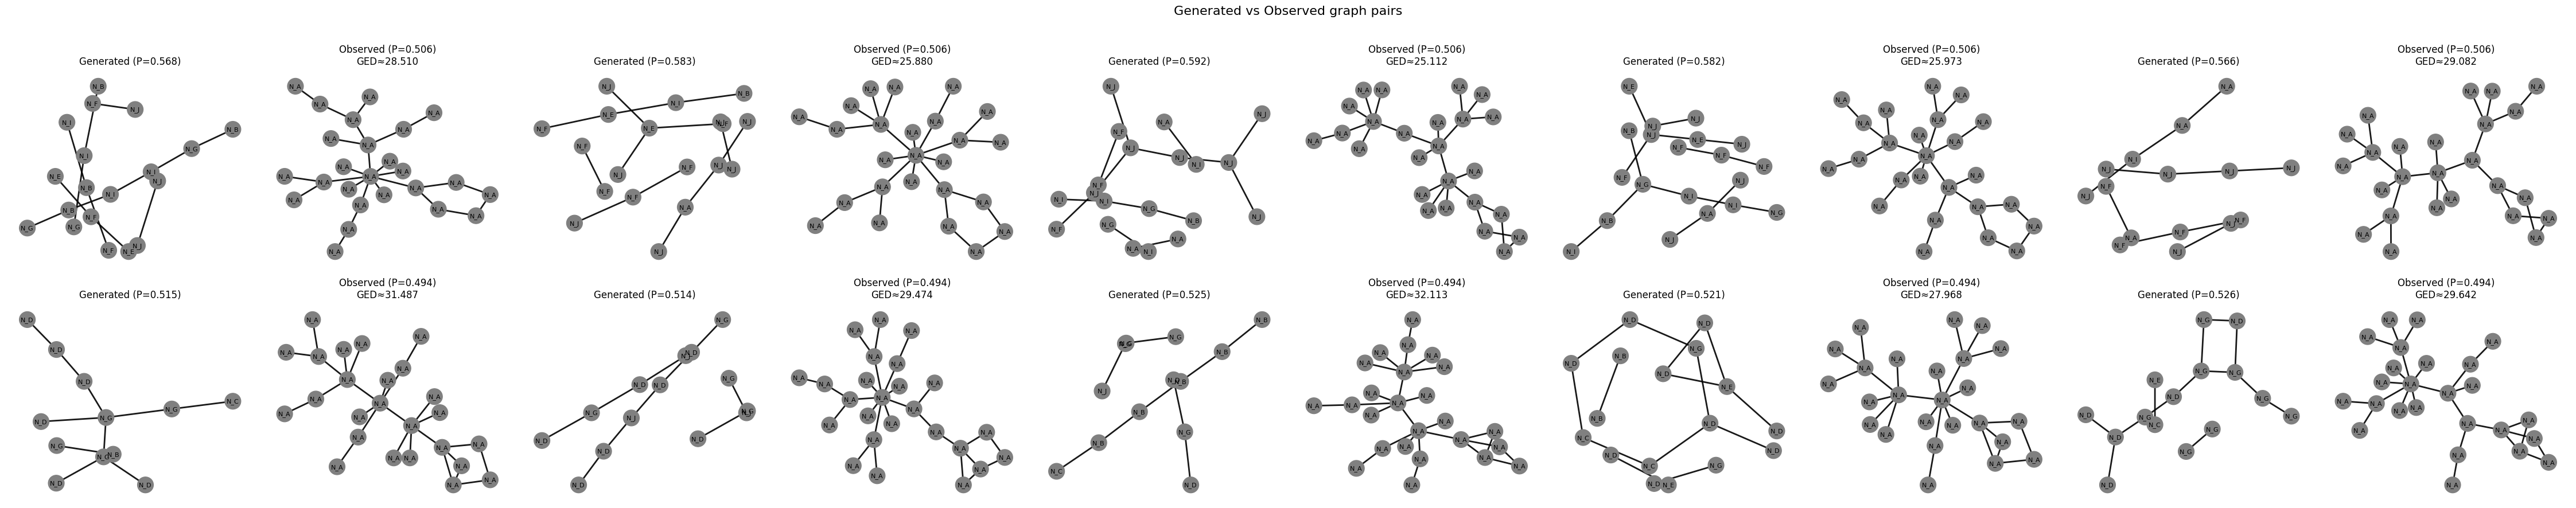

In [57]:
import new_src.utils
importlib.reload(new_src.utils)

from new_src.utils import eval_plot 

eval_plot(
    explainee, 
    graphs_0, 
    graphs_1, 
    obs_graphs_0=cls_split[0], 
    obs_graphs_1=cls_split[1],
    ged_model=model, 
    dataset=data,
    layout="kamada"
)